# Parameters

In [1]:
import sys
import os
from pathlib import Path
import pandas as pd

# ===== CONFIGURAÇÃO DE CAMINHOS =====
current_notebook = Path.cwd()  
project_root = current_notebook.parent.parent 

# Adiciona o diretório raiz ao sys.path
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Adiciona o diretório Modules ao sys.path
modules_dir = project_root / "Modules"
if str(modules_dir) not in sys.path:
    sys.path.insert(0, str(modules_dir))

# ===== IMPORTS DOS MÓDULOS =====
import Modules.ClusterDBSCANModule as cluster
import Modules.FutureAnalysisModule as fa
from Modules.config import CONFIG

# ===== CONFIGURAÇÕES DO PROJETO =====
DATAPATH = CONFIG["datapath"]
COVID_TRAIN_DATA_FILE = CONFIG["covid_train_data_file"]
COVID_TEST_DATA_FILE = CONFIG["covid_test_data_file"]
FUTURE_DATA_FILE = CONFIG["future_data_file"]

FIGSIZE_CLUSTER_HEATMAP = CONFIG["figsize_cluster_heatmap"]
FIGSIZE_FUTURE_HEATMAP = CONFIG["figsize_future_heatmap"]
IMAGES_SAVE_PATH = CONFIG["image_save_path"]

TRIALS_OPTUNA = 250

# Import data

In [2]:
# ===== CARREGAMENTO DOS DADOS =====
data_folder = current_notebook / DATAPATH

covid_train = pd.read_csv(data_folder / COVID_TRAIN_DATA_FILE)
covid_test = pd.read_csv(data_folder / COVID_TEST_DATA_FILE)
future_data = pd.read_csv(data_folder / FUTURE_DATA_FILE)

# Feature engineering: morte após a internação
covid_train['died_after'] = ((covid_train['died'] == 1) & (covid_train['died_in_stay'] == 0)).astype(int)
covid_test['died_after'] = ((covid_test['died'] == 1) & (covid_test['died_in_stay'] == 0)).astype(int)
future_data['died_after'] = ((future_data['died'] == 1) & (future_data['died_in_stay'] == 0)).astype(int)

In [3]:
data_covid = pd.concat([covid_train, covid_test], axis=0)
data_covid = data_covid.sample(frac=1, random_state=42).reset_index(drop=True)

# Mice Data

In [4]:
categorical_features = [
            "myocardial_infarct",
            "congestive_heart_failure",
            "peripheral_vascular_disease",
            "cerebrovascular_disease",
            "dementia",
            "chronic_pulmonary_disease",
            "rheumatic_disease",
            "peptic_ulcer_disease",
            "mild_liver_disease",
            "diabetes_without_cc",
            "diabetes_with_cc",
            "paraplegia",
            "renal_disease",
            "malignant_cancer",
            "severe_liver_disease",
            "metastatic_solid_tumor",
            "aids",
            "gender_M",
            "died_in_stay",
            "died_after",
            "died",
            "COVID"
        ]

In [5]:
features_not_considered = ['died', 'died_in_stay', 'died_after', 'COVID', 'subject_id', 'hadm_id']

In [6]:
helper = cluster.DBSCANClusterHelper(data=data_covid, features_not_considered=features_not_considered)

2026-02-19 19:22:33,139 - ClusterBaseModule - INFO - ClusterBaseHelper initialized: 3355 records, 67 features (22 categorical, 51 numerical)
2026-02-19 19:22:33,140 - Modules.ClusterDBSCANModule - INFO - DBSCANClusterHelper initialized: 3355 records, scaler='standard'


## Find best hyperparameters for DBSCAN

In [7]:
param = {
    "eps": {"min": 1e-3, "max": 10},
    "min_samples": {"min": 1, "max": 100}
}

### DBCV

In [ ]:
# os.environ["PYTHONWARNINGS"] = "ignore"
# dbcv_df, dbcv_param, dbcv_best = helper.optunaGridSearch(
#     parameters=param, 
#     n_trials=TRIALS_OPTUNA, 
#     saveStorage=True, 
#     metric="dbcv",
#     restrictMinsizeCluster=2,
#     restrictMaxsizeCluster=80
# )

In [9]:
dbcv_param = {'eps': 5.977380553834922, 'min_samples': 86}

### DISCO

In [10]:
# os.environ['PYTHONWARNINGS'] = 'ignore'
# disco_df, disco_param, disco_best = helper.optunaGridSearch(
#     parameters=param, 
#     n_trials=TRIALS_OPTUNA, 
#     saveStorage=True, 
#     metric="disco",
#     restrictMinsizeCluster=2,
#     restrictMaxsizeCluster=80
# )

In [11]:
disco_param = {'eps': 5.936693936256001, 'min_samples': 69}

### DSI

In [12]:
# os.environ['PYTHONWARNINGS'] = 'ignore'
# dsi_df, dsi_param, dsi_best = helper.optunaGridSearch(
#     parameters=param, 
#     n_trials=TRIALS_OPTUNA, 
#     saveStorage=True, 
#     metric="dsi",
#     restrictMinsizeCluster=2,
#     restrictMaxsizeCluster=80
# )

In [13]:
dsi_param = {'eps': 4.6004262102394975, 'min_samples': 3}

### Silhouette

In [14]:
# os.environ['PYTHONWARNINGS'] = 'ignore'
# silhouette_df, silhouette_param, silhouette_best = helper.optunaGridSearch(
#     parameters=param, 
#     n_trials=TRIALS_OPTUNA, 
#     saveStorage=True, 
#     metric="silhouette",
#     restrictMinsizeCluster=2,
#     restrictMaxsizeCluster=80
# )

In [15]:
silhouette_param = {'eps': 5.889620324914935, 'min_samples': 41}

## DBCV - Best Result

In [16]:
helper.clustering(eps=dbcv_param["eps"], min_samples=dbcv_param["min_samples"])
helper.get_metrics()

2026-02-19 19:23:04,060 - ClusterBaseModule - INFO - Clustered data set: 3355 records, 2 clusters
2026-02-19 19:23:04,061 - Modules.ClusterDBSCANModule - INFO - DBSCAN clustering complete: eps=5.977380553834922, min_samples=86
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)
2026-02-19 19:23:08,284 - ClusterBaseModule - INFO - Calculated metrics: silhouette=0.408, dbcv=0.800, dsi=0.215, disco=-0.368


{'silhouette': 0.408,
 'dbcv': 0.7997015027138211,
 'dsi': np.float64(0.215),
 'disco': np.float64(-0.3682794989691964)}

In [17]:
helper.clustering(eps=disco_param["eps"], min_samples=disco_param["min_samples"])
helper.get_metrics()

2026-02-19 19:23:10,398 - ClusterBaseModule - INFO - Clustered data set: 3355 records, 2 clusters
2026-02-19 19:23:10,399 - Modules.ClusterDBSCANModule - INFO - DBSCAN clustering complete: eps=5.936693936256001, min_samples=69
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)
2026-02-19 19:23:14,727 - ClusterBaseModule - INFO - Calculated metrics: silhouette=0.408, dbcv=0.798, dsi=0.216, disco=-0.368


{'silhouette': 0.408,
 'dbcv': 0.7976147010968485,
 'dsi': np.float64(0.216),
 'disco': np.float64(-0.36804110089796044)}

In [18]:
helper.clustering(eps=dsi_param["eps"], min_samples=dsi_param["min_samples"])
helper.get_metrics()

2026-02-19 19:23:16,151 - ClusterBaseModule - INFO - Clustered data set: 3355 records, 6 clusters
2026-02-19 19:23:16,152 - Modules.ClusterDBSCANModule - INFO - DBSCAN clustering complete: eps=4.6004262102394975, min_samples=3
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_

{'silhouette': -0.36,
 'dbcv': 0.5806252036020639,
 'dsi': np.float64(0.413),
 'disco': np.float64(-0.3588043840139868)}

In [19]:
helper.clustering(eps=silhouette_param["eps"], min_samples=silhouette_param["min_samples"])
helper.get_metrics()

2026-02-19 19:23:21,509 - ClusterBaseModule - INFO - Clustered data set: 3355 records, 2 clusters
2026-02-19 19:23:21,509 - Modules.ClusterDBSCANModule - INFO - DBSCAN clustering complete: eps=5.889620324914935, min_samples=41
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)
2026-02-19 19:23:25,769 - ClusterBaseModule - INFO - Calculated metrics: silhouette=0.412, dbcv=0.799, dsi=0.221, disco=-0.366


{'silhouette': 0.412,
 'dbcv': 0.7991050125712447,
 'dsi': np.float64(0.221),
 'disco': np.float64(-0.36647018698335904)}

## Best Overall Result - Silhouette

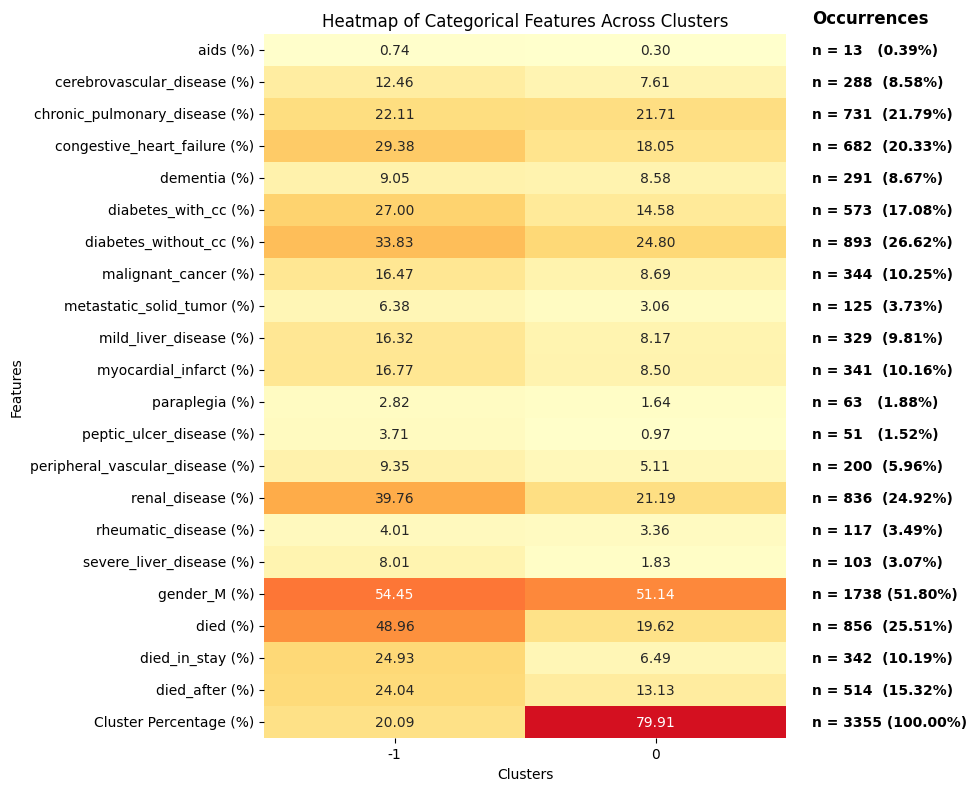

In [ ]:
helper.heatmap_clusters_categorical(
    figsize=FIGSIZE_CLUSTER_HEATMAP,
    savepath=IMAGES_SAVE_PATH + "dbscan-all-categorical"
)

/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/sklearn/utils/v

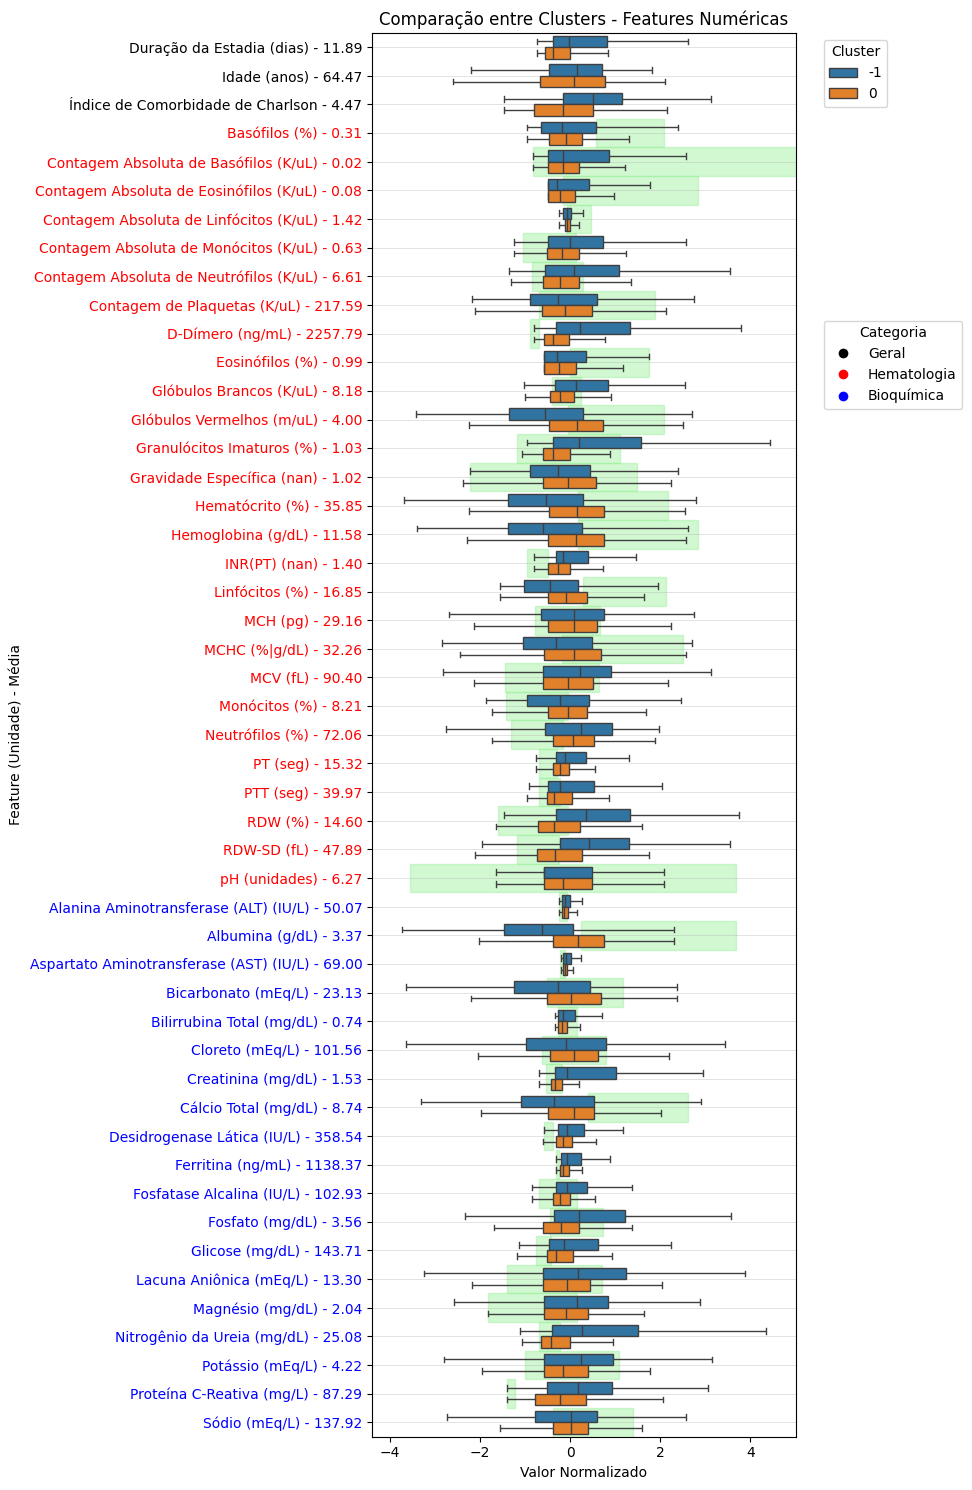

2026-02-19 19:24:30,067 - ClusterBaseModule - INFO - Displayed numerical comparison: 49 features, 2 clusters


[('D-Dimer_Hematology_Blood_ng/mL|ng/mL FEU',
  np.float64(1.9810630182065774e-63)),
 ('Urea Nitrogen_Chemistry_Blood_mg/dL', np.float64(8.578251206249798e-59)),
 ('Albumin_Chemistry_Blood_g/dL', np.float64(2.635893348480726e-58)),
 ('Immature Granulocytes_Hematology_Blood_%',
  np.float64(6.562134494545446e-57)),
 ('RDW-SD_Hematology_Blood_fL', np.float64(1.4688385183461846e-49)),
 ('Creatinine_Chemistry_Blood_mg/dL', np.float64(2.023924249694086e-47)),
 ('RDW_Hematology_Blood_%', np.float64(5.315404477451799e-46)),
 ('Hemoglobin_Hematology_Blood_g/dL', np.float64(7.478903255121685e-42)),
 ('length_of_stay_days', np.float64(1.6387409962868484e-40)),
 ('Red Blood Cells_Hematology_Blood_m/uL', np.float64(3.321793830543047e-39)),
 ('Hematocrit_Hematology_Blood_%', np.float64(1.325734648037306e-38)),
 ('White Blood Cells_Hematology_Blood_K/uL',
  np.float64(3.945687890290267e-36)),
 ('Phosphate_Chemistry_Blood_mg/dL', np.float64(1.3785233950700942e-34)),
 ('Lymphocytes_Hematology_Blood_%'

In [21]:
helper.show_cluster_compare_numerical(
    figsize=(10, 15),
    # savepath=IMAGES_SAVE_PATH + "dbscan-all-numerical",
)

In [ ]:
selected_clusters = [-1, 0]

In [ ]:
helper.set_clustered_autoencoder()

Autoencoder is not fitted yet, will be pretrained.
Start training with clustering loss.
Epoch: 100%|██████████| 100/100 [00:23<00:00,  4.21it/s]


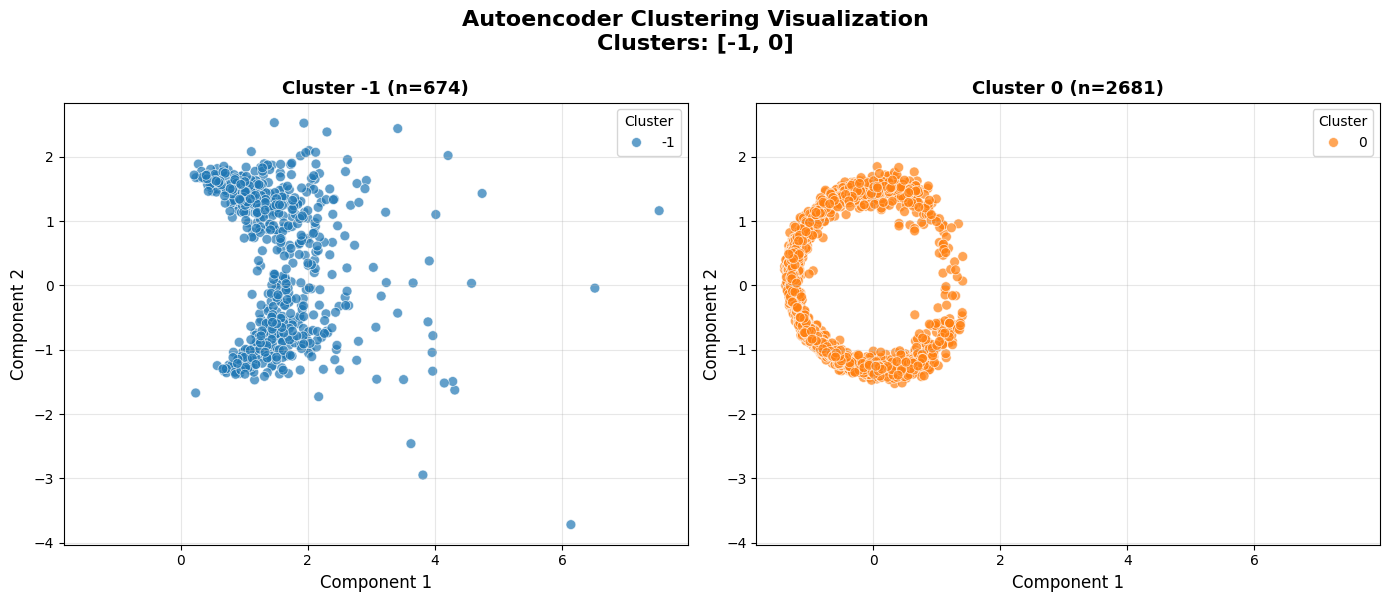

In [ ]:
helper.show_clustered_autoencoder(selected_clusters=selected_clusters, savepath=IMAGES_SAVE_PATH + "dbscan-autoencoder-all")

##### Future data


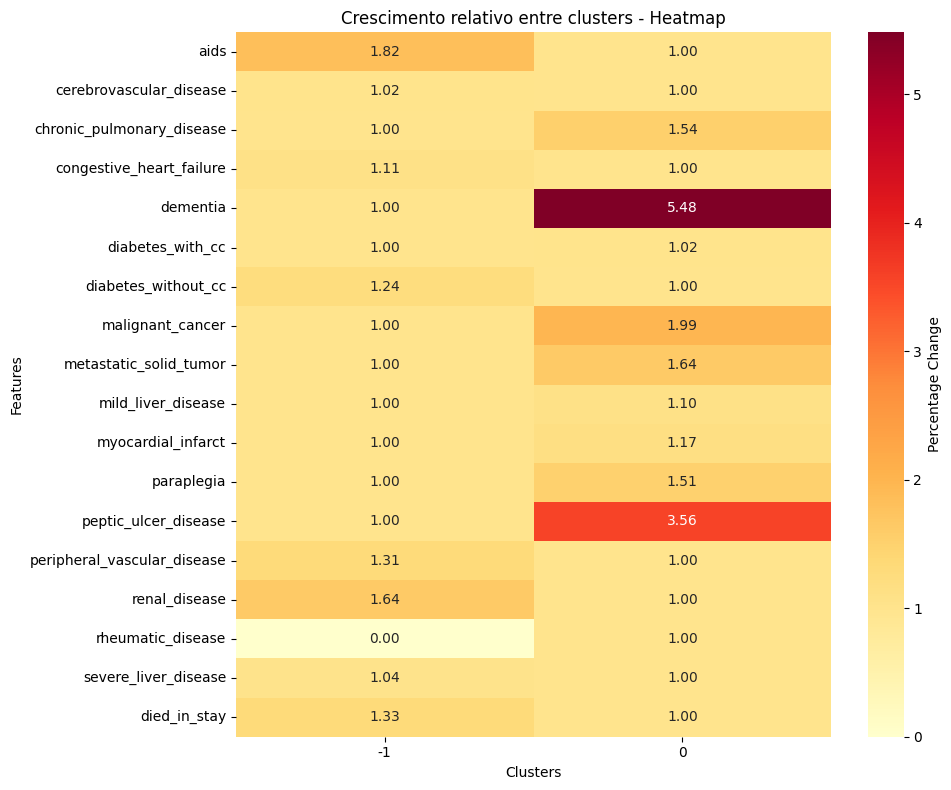

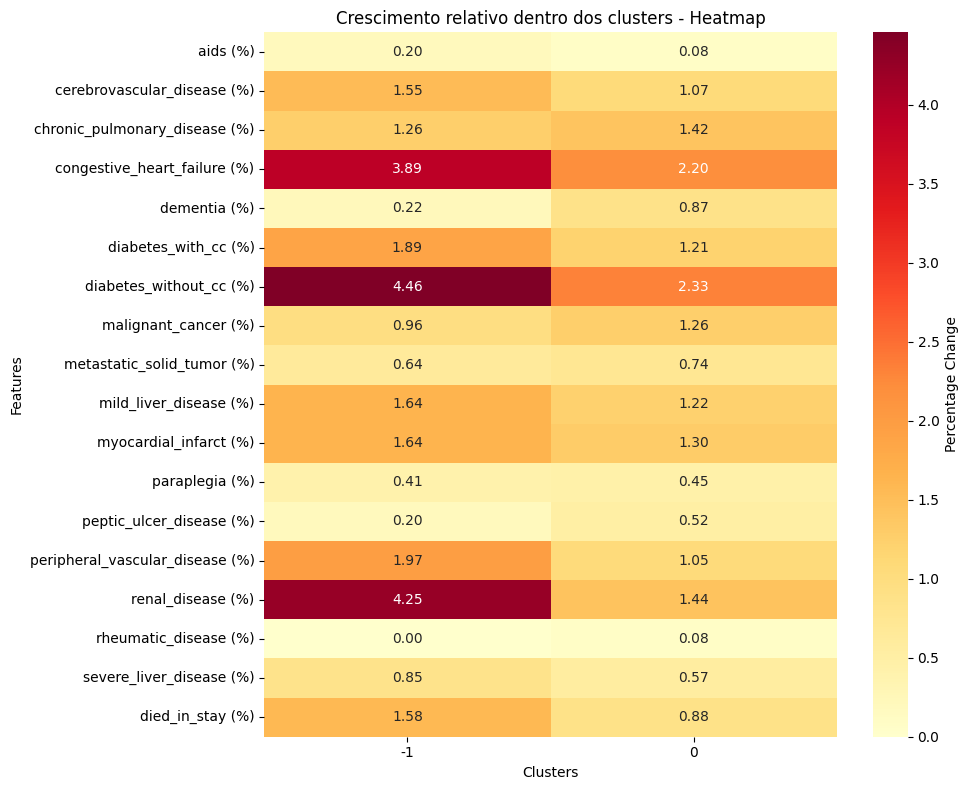

In [ ]:
future_helper = fa.FutureAnalysisHelper(
    helper.clustered_data, future_data, control, control_readmission
)
delta = future_helper.get_delta_clusters(percentage=True, relative_total=True)
future_helper.show_delta_heatmap(
    figsize=FIGSIZE_FUTURE_HEATMAP,
    relative_total=True,
    selected_clusters=selected_clusters,
    savepath=IMAGES_SAVE_PATH + "dbscan-all-future",
)

In [ ]:
future_helper.getMeanReadmission()

{'Mean readmission Cluster -1': 2.51,
 'Mean readmission Cluster 0': 2.26,
 'Overall Mean readmission': 2.31}

In [ ]:
future_helper.getMeanDaysGap()

{'Mean days gap Cluster -1': 121.78,
 'Mean days gap Cluster 0': 129.05,
 'Overall Mean days gap': 127.49}

In [ ]:
future_helper.getMortalityRates(onlyFirstAdmission=True)

{'Mortality rate Cluster -1': 0.05,
 'Mortality rate Cluster 0': 0.13,
 'Overall Mortality rate': 0.09}

# Add logs

In [ ]:
log_file = "../log.csv"
current_dir = os.getcwd()
log_file_path = os.path.join(current_dir, log_file)

metrics = helper.getMetrics()

# Add line to save log
if os.path.exists(log_file_path):
    with open(log_file_path, 'a') as f:
        f.write(f"DBSCAN, None, Comprehensive, {metrics['disco']}, {metrics['dbcv']}, {metrics['dsi']}, {metrics['silhouette']}\n")

/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)
